Successfully included: pakistan_weather_clean_final.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31779 entries, 0 to 31778
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           31779 non-null  datetime64[ns]
 1   season         31779 non-null  object        
 2   city           31779 non-null  object        
 3   tmin           31779 non-null  float64       
 4   tmax           31779 non-null  float64       
 5   tavg           31779 non-null  float64       
 6   precipitation  31779 non-null  float64       
 7   wind_speed     31779 non-null  float64       
 8   humidity       31779 non-null  int64         
 9   pressure       31779 non-null  float64       
dtypes: datetime64[ns](1), float64(6), int64(1), object(2)
memory usage: 2.4+ MB
None
                tavg  precipitation   humidity  wind_speed     pressure
city                                                             

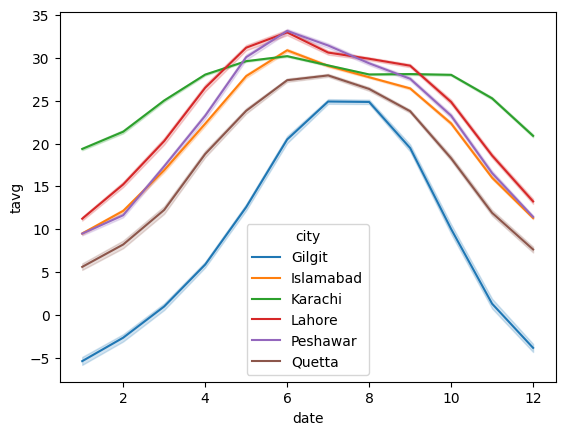

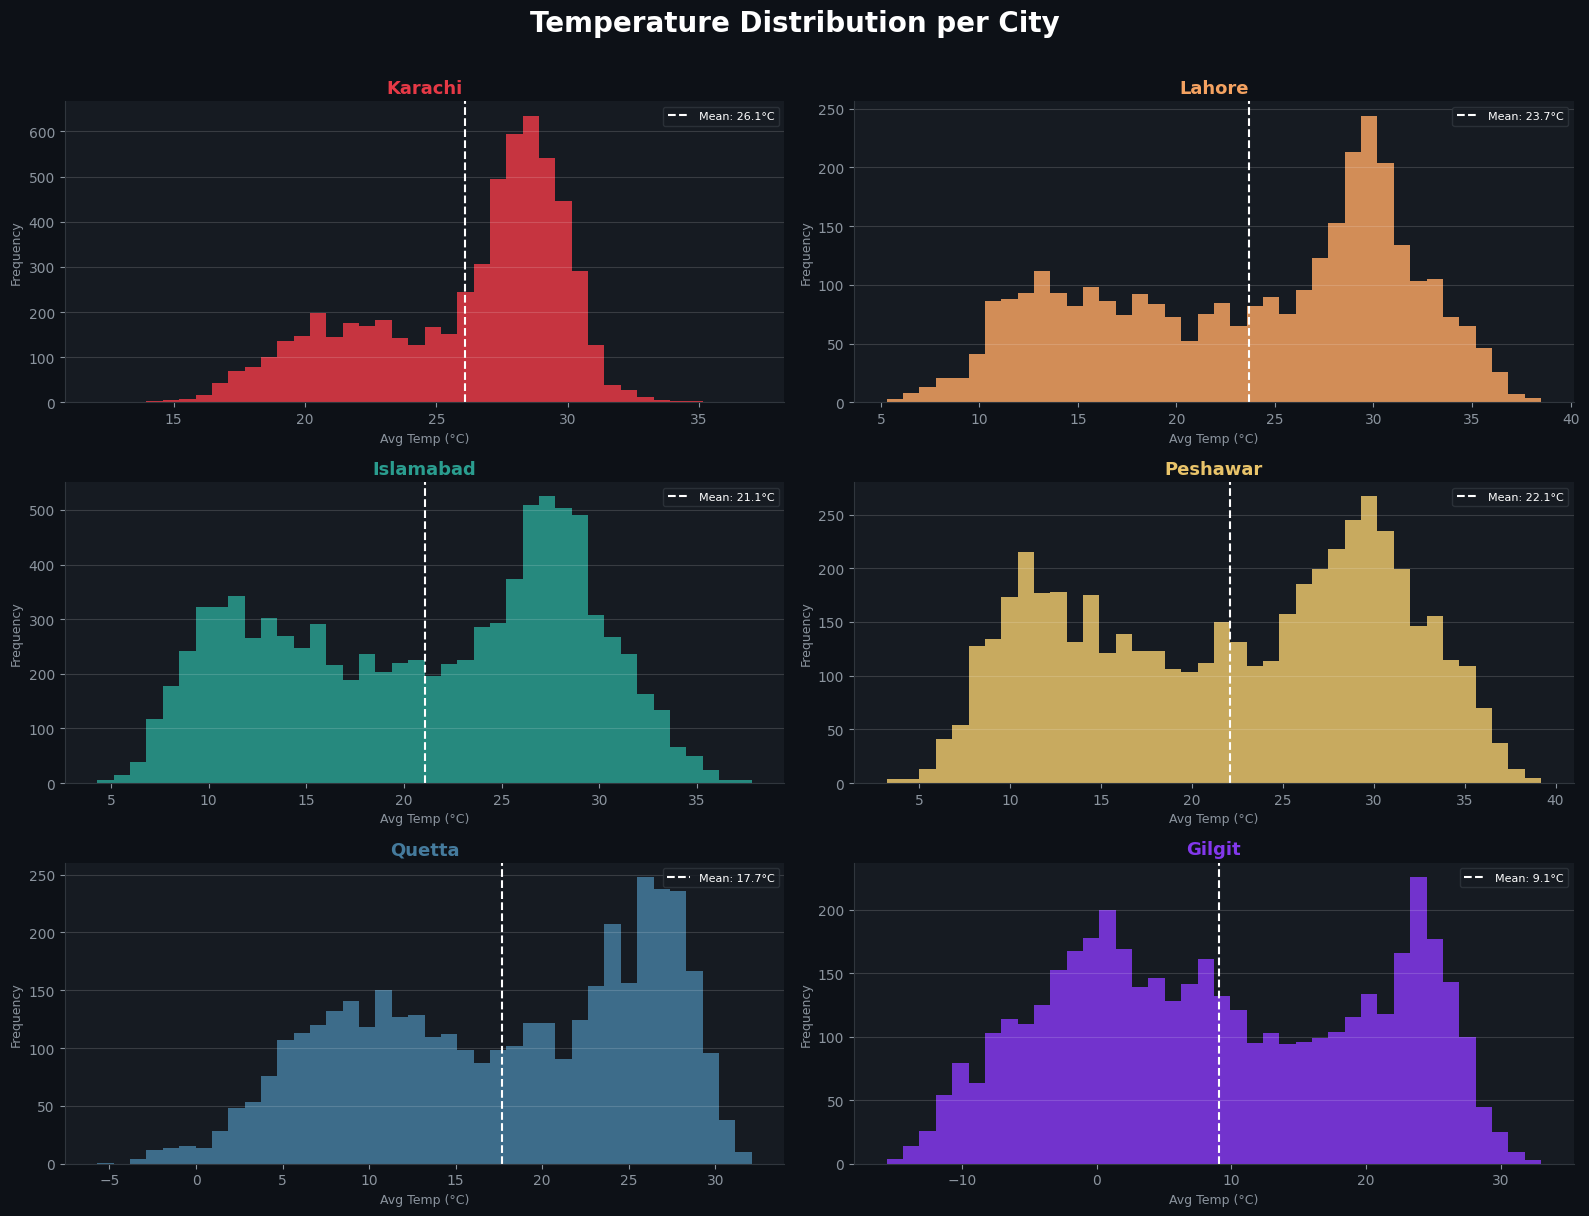

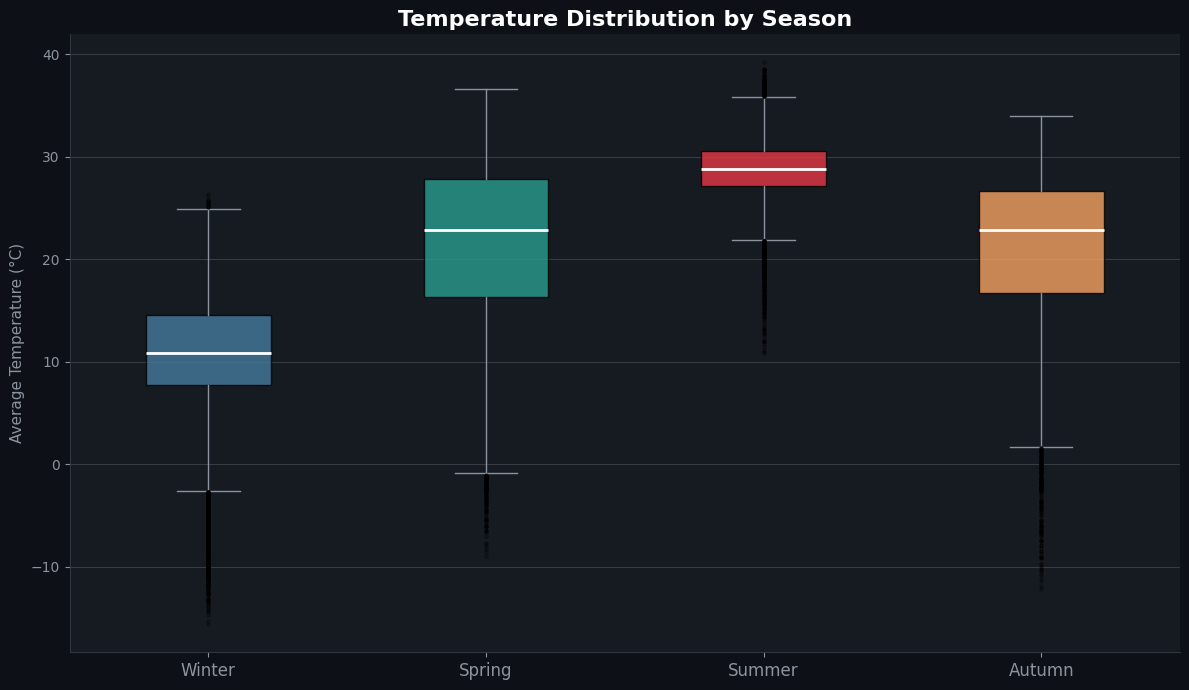

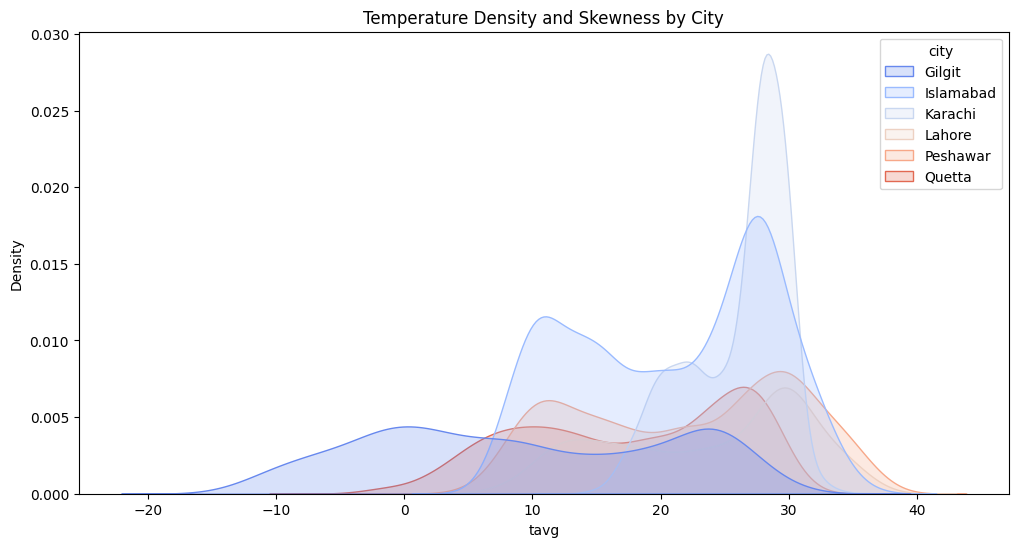

In [ ]:
# 1. Data Manipulation and Loading
import pandas as pd
import numpy as np
# 2. Statistical Analysis
from scipy import stats
# 3. Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from scipy.stats import norm, kstest, normaltest, poisson
import warnings
warnings.filterwarnings('ignore')
# 4. Machine Learning & Regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# Load the dataset verbatim as required
file_name = "pakistan_weather_clean_final.csv"
try:
    # Reading the data
    df = pd.read_csv(file_name)
    # Converting date to datetime objects for time-series analysis
    df['date'] = pd.to_datetime(df['date'])
    print(f"Successfully included: {file_name}")
    print(df.info()) # Verify variables and data types
except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found in the directory.")
# Tabular: Average metrics grouped by city
city_stats = df.groupby('city')[['tavg', 'precipitation', 'humidity', 'wind_speed', 'pressure']].mean()
print(city_stats)
# Graphical: Line plot for seasonal temperature trends across cities
sns.lineplot(data=df, x=df['date'].dt.month, y='tavg', hue='city')
#Second Part
df['year'] = df['date'].dt.year
CITIES = ['Karachi', 'Lahore', 'Islamabad', 'Peshawar', 'Quetta', 'Gilgit']
CITY_COLORS = {
    'Karachi':   '#E63946',
    'Lahore':    '#F4A261',
    'Islamabad': '#2A9D8F',
    'Peshawar':  '#E9C46A',
    'Quetta':    '#457B9D',
    'Gilgit':    '#8338EC'
}
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.patch.set_facecolor('#0D1117')
fig.suptitle('Temperature Distribution per City', fontsize=20, fontweight='bold', color='white', y=1.01)
for ax, city in zip(axes.flatten(), CITIES):
    city_df = df[df['city'] == city]['tavg']
    ax.set_facecolor('#161B22')
    ax.hist(city_df, bins=40, color=CITY_COLORS[city], alpha=0.85, edgecolor='none')
    ax.axvline(city_df.mean(), color='white', linewidth=1.5, linestyle='--',
               label=f'Mean: {city_df.mean():.1f}°C')
    ax.set_title(city, fontsize=13, fontweight='bold', color=CITY_COLORS[city])
    ax.set_xlabel('Avg Temp (°C)', color='#8B949E', fontsize=9)
    ax.set_ylabel('Frequency', color='#8B949E', fontsize=9)
    ax.tick_params(colors='#8B949E')
    ax.spines[['top','right']].set_visible(False)
    for spine in ['bottom','left']: ax.spines[spine].set_color('#30363D')
    ax.grid(True, alpha=0.15, color='white', axis='y')
    ax.legend(fontsize=8, labelcolor='white', facecolor='#161B22', edgecolor='#30363D')
plt.tight_layout()
plt.show()
#boxplot-season
SEASON_COLORS = {
    'Winter': '#457B9D',
    'Spring': '#2A9D8F',
    'Summer': '#E63946',
    'Autumn': '#F4A261'
}
seasons = ['Winter', 'Spring', 'Summer', 'Autumn']
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#161B22')
data_by_season = [df[df['season'] == s]['tavg'].values for s in seasons]
bp = ax.boxplot(data_by_season, patch_artist=True,
                medianprops=dict(color='white', linewidth=2),
                whiskerprops=dict(color='#8B949E'),
                capprops=dict(color='#8B949E'),
                flierprops=dict(marker='o', markersize=2, alpha=0.4))
for patch, s in zip(bp['boxes'], seasons):
    patch.set_facecolor(SEASON_COLORS[s])
    patch.set_alpha(0.8)
ax.set_xticks(range(1, len(seasons)+1))
ax.set_xticklabels(seasons, color='white', fontsize=12)
ax.set_ylabel('Average Temperature (°C)', color='#8B949E', fontsize=11)
ax.set_title('Temperature Distribution by Season', fontsize=16, fontweight='bold', color='white')
ax.tick_params(colors='#8B949E')
ax.spines[['top','right']].set_visible(False)
for spine in ['bottom','left']: ax.spines[spine].set_color('#30363D')
ax.grid(True, alpha=0.15, color='white', axis='y')
plt.tight_layout()
plt.show()
# 2. Graphical Analysis: Density & Skewness
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df, x='tavg', hue='city', fill=True, palette='coolwarm')
plt.title('Temperature Density and Skewness by City')
plt.savefig('city_skewness_analysis.png')

--- TABLE 1: Global Descriptive Statistics ---
           tavg  precipitation  humidity  pressure
count  31779.00       31779.00  31779.00  31779.00
mean      20.36           1.72     58.14   1010.83
std        9.57           5.97     18.46      8.48
min      -15.60           0.00      6.00    989.70
25%       13.50           0.00     45.00   1004.00
50%       22.70           0.00     61.00   1011.40
75%       28.00           0.50     73.00   1016.80
max       39.20         201.10     96.00   1042.90


--- TABLE 2: 95% Confidence Intervals by City (Temperature) ---
     City  Mean Temp (°C)  95% CI Lower (°C)  95% CI Upper (°C)  Record Count
   Gilgit            9.11               8.77               9.45          4383
Islamabad           21.08              20.92              21.23          9132
  Karachi           26.11              26.01              26.21          5844
   Lahore           23.67              23.40              23.93          3288
 Peshawar           22.09             

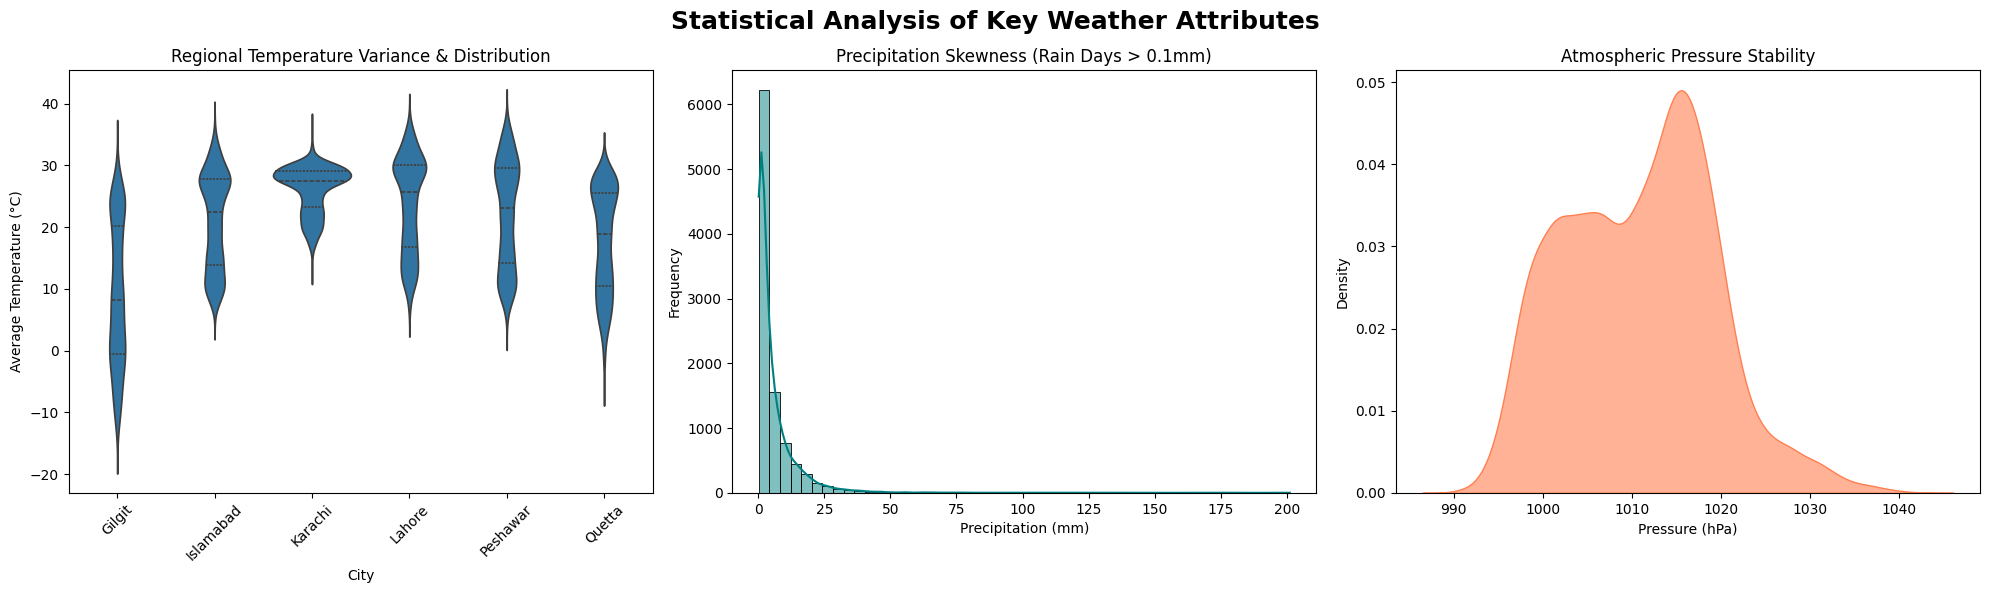

In [ ]:
print("--- TABLE 1: Global Descriptive Statistics ---")
# Focus on the most important attributes identified in the analysis
key_attributes = ['tavg', 'precipitation', 'humidity', 'pressure']
desc_stats = df[key_attributes].describe()
print(desc_stats.round(2))
print("\n")
print("--- TABLE 2: 95% Confidence Intervals by City (Temperature) ---")
# Calculate localized 95% CIs to prove regional climate differences
ci_results = []
for city in sorted(df['city'].unique()):
    city_data = df[df['city'] == city]['tavg'].dropna()
    n = len(city_data)
    mean = np.mean(city_data)
    se = stats.sem(city_data)
    ci = stats.t.interval(0.95, n-1, loc=mean, scale=se)
    ci_results.append({
        'City': city,
        'Mean Temp (°C)': round(mean, 2),
        '95% CI Lower (°C)': round(ci[0], 2),
        '95% CI Upper (°C)': round(ci[1], 2),
        'Record Count': n
    })
ci_df = pd.DataFrame(ci_results)
print(ci_df.to_string(index=False))
print("\n")
# Create a figure with 3 subplots for the presentation
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Statistical Analysis of Key Weather Attributes', fontsize=18, fontweight='bold')
# GRAPH 1: Temperature Variance by City (Violin Plot)
# Proves that global CIs are invalid and regional CIs are required
sns.violinplot(data=df, x='city', y='tavg', ax=axes[0], inner="quartile")
axes[0].set_title('Regional Temperature Variance & Distribution')
axes[0].set_xlabel('City')
axes[0].set_ylabel('Average Temperature (°C)')
axes[0].tick_params(axis='x', rotation=45)
# GRAPH 2: Extreme Precipitation Skewness (Histogram with KDE)
# Proves the extreme right-skew (anomalous massive rainfall events vs dry days)
# Filtering out absolute 0s just to show the distribution of actual rain events
rain_data = df[df['precipitation'] > 0.1]
sns.histplot(data=rain_data, x='precipitation', bins=50, kde=True, ax=axes[1], color='teal')
axes[1].set_title('Precipitation Skewness (Rain Days > 0.1mm)')
axes[1].set_xlabel('Precipitation (mm)')
axes[1].set_ylabel('Frequency')
# GRAPH 3: Pressure Stability (KDE Plot)
# Proves that atmospheric pressure is highly stable (tight distribution)
sns.kdeplot(data=df, x='pressure', fill=True, ax=axes[2], color='coral', alpha=0.6)
axes[2].set_title('Atmospheric Pressure Stability')
axes[2].set_xlabel('Pressure (hPa)')
axes[2].set_ylabel('Density')
# Adjust layout and save the graph for your report
plt.tight_layout()
plt.subplots_adjust(top=0.88) # Adjust top to make room for the main title
plt.savefig('statistical_analysis_attributes.png', dpi=300)
print("Visualizations saved successfully as 'statistical_analysis_attributes.png'.")

--- SEASONAL DISTRIBUTION SUITABILITY TABLE ---
   City Season  Mean Temp (°C)  Normal AIC  GMM AIC Best Fit
 Gilgit Winter            -4.0        6385     6313      GMM
 Gilgit Spring             6.5        7101     7098      GMM
 Gilgit Summer            23.4        6067     5959      GMM
 Gilgit Autumn            10.3        7896     7837      GMM
 Lahore Winter            13.2        4020     4020   Normal
 Lahore Spring            26.0        5175     5108      GMM
 Lahore Summer            31.1        3898     3850      GMM
 Lahore Autumn            24.2        4885     4748      GMM
Karachi Winter            20.5        6251     6253   Normal
Karachi Spring            27.6        6747     6538      GMM
Karachi Summer            29.1        4905     4875      GMM
Karachi Autumn            27.1        6041     5964      GMM


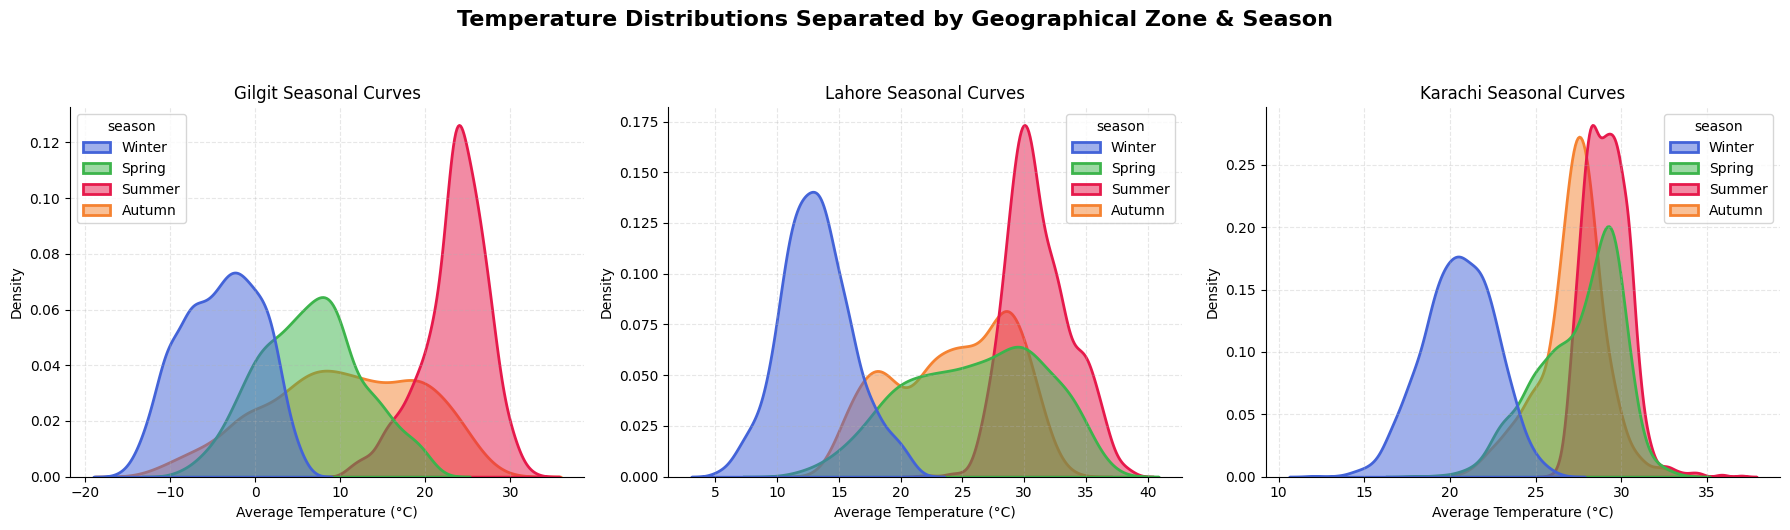

In [ ]:
df = df.dropna(subset=['tavg'])
df['date'] = pd.to_datetime(df['date'])

def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'

df['season'] = df['date'].dt.month.apply(get_season)

# Select contrasting cities for clear analysis
sample_cities = ['Gilgit', 'Lahore', 'Karachi']

# 2. TABULAR ANALYSIS: Normal vs GMM Suitability per Season
results = []
for city in sample_cities:
    for season in ['Winter', 'Spring', 'Summer', 'Autumn']:
        subset = df[(df['city'] == city) & (df['season'] == season)]['tavg'].values
        if len(subset) < 10: continue

        # Fit Normal Distribution and calculate AIC
        mu, std = stats.norm.fit(subset)
        aic_norm = 2*2 - 2*stats.norm.logpdf(subset, mu, std).sum()

        # Fit GMM (2-Components) and calculate AIC
        gmm = GaussianMixture(n_components=2, random_state=42).fit(subset.reshape(-1, 1))
        aic_gmm = gmm.aic(subset.reshape(-1, 1))

        # Compare models (Lower AIC is mathematically superior)
        best_fit = 'Normal' if aic_norm <= aic_gmm else 'GMM'

        results.append({
            'City': city, 'Season': season, 'Mean Temp (°C)': round(mu, 1),
            'Normal AIC': round(aic_norm), 'GMM AIC': round(aic_gmm),
            'Best Fit': best_fit
        })

table_df = pd.DataFrame(results)
print("--- SEASONAL DISTRIBUTION SUITABILITY TABLE ---")
print(table_df.to_string(index=False))

# 3. GRAPHICAL ANALYSIS: Seasonal KDE Density Curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
fig.suptitle('Temperature Distributions Separated by Geographical Zone & Season',
             fontsize=16, fontweight='bold', y=1.05)

for idx, city in enumerate(sample_cities):
    city_data = df[df['city'] == city]
    # Plot overlapping seasonal density curves
    sns.kdeplot(data=city_data, x='tavg', hue='season', ax=axes[idx], fill=True,
                palette=['#4363d8', '#3cb44b', '#e6194b', '#f58231'],
                hue_order=['Winter', 'Spring', 'Summer', 'Autumn'],
                common_norm=False, alpha=0.5, linewidth=2)

    axes[idx].set_title(f'{city} Seasonal Curves')
    axes[idx].set_xlabel('Average Temperature (°C)')
    axes[idx].set_ylabel('Density')

sns.despine()
plt.tight_layout()
plt.savefig('seasonal_geographical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()